In [1]:
import re
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm
import numpy as np

In [2]:
def extract_epoch_data(file_path):
    # Pattern to match the metrics in the line
    pattern = r"(?P<name>\w+)=?(?P<value>[\d.]+)"

    # Dictionary to store all metrics
    all_data = {}

    with open(file_path, 'r') as file:
        for line in file:
            # Extract epoch number
            epoch_match = re.search(r"Epoch (\d+):", line)
            if epoch_match:
                epoch_num = int(epoch_match.group(1))
                metrics = re.findall(pattern, line)
                
                # Add the data to the dictionary
                epoch_data = {}
                for name, value in metrics:
                    try: 
                        epoch_data[name] = float(value)
                    except: 
                        continue
                
                all_data[epoch_num] = epoch_data

    return all_data

In [3]:
def neo_plotter(epoch_dict, components_to_extract, domain = [10, 1000], y_lim = None, colorlist = ['Blues',
          'Greens', 
          'Oranges', 
          'Purples', 
          'Reds']): 
    plt.figure(figsize=(10, 5))
    plotting_data = {}
    counter = 0 
    for my_label, epoch_data in epoch_dict.items(): 
        
        epochs = list(epoch_data.keys())
        # Generate a color palette
        cmap = plt.colormaps[colorlist[counter]]
        
        start = 0.5  # Adjust start and end to get the desired shade range
        end = 1.0
        colors = [cmap(x) for x in np.linspace(start, end, len(components_to_extract))]


        for i, component in enumerate(components_to_extract): 
            plotting_data[component] = [per_epoch_data[component] for epoch_number, per_epoch_data  in epoch_data.items()]
            component_label = str(my_label) + "_" + str(component)
            print(len(plotting_data[component]))
            plt.plot(list(range(domain[0], domain[1])), plotting_data[component][domain[0]:domain[1]], 
                     label=component_label, color = colors[i])
        counter += 1
        
    plt.xlabel("Epochs")
    plt.legend()
    plt.grid(True)
    if y_lim is not None: 
        plt.ylim(0, y_lim)
    plt.tight_layout()
    plt.show()

In [4]:
def plotter(file_paths, values='train_loss'):
    plt.figure(figsize=(10, 5))
    for my_label, file_path in file_paths.items(): 
        print(file_path)
        epoch_data = extract_epoch_data(file_path)

        # Extract training and validation losses for plotting for both files
        epochs = list(epoch_data.keys())
        train_losses = [epoch['loss'] for epoch in epoch_data.values() if epoch['loss'] <= 20]
        val_losses = [epoch['val_loss'] for epoch in epoch_data.values() if epoch['loss'] <= 20]
        
        if values == 'train_loss': 
            plt.plot(range(len(train_losses)), train_losses, label=my_label)
        elif values == 'val_loss': 
            plt.plot(range(len(val_losses)), val_losses, label=my_label)
    plt.title("{} per Epoch".format(values))
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [5]:
def epoch_dict_getter(file_paths): 
    epoch_dict = {}
    for my_label, file_path in file_paths.items():
        print(my_label)
        epoch_data = extract_epoch_data(file_path)
        epoch_dict[my_label] = epoch_data
        
    return(epoch_dict)

Example of data: 

{0: {'10': 6.0,
  '0': 0.0,
  'loss': 44.9,
  'ym': 8.0,
  'val_loss': 1.11,
  'val_natom_loss': 16.5,
  'val_lattice_loss': 75.0,
  'val_coord_loss': 1.11,
  'val_type_loss': 2.29,
  'val_kld_loss': 0.0,
  'val_composition_loss': 5.72,
  'val_diffraction_loss': 0.0,
  'val_property_loss': 0.0,
  'val_natom_accuracy': 0.0391,
  'val_lengths_mard': 2.45,
  'val_angles_mae': 96.2,
  'val_volumes_mard': 3.44,
  'val_type_accuracy': 0.338,
  'train_loss_step': 44.0,
  'train_natom_loss_step': 2.08,
  'train_lattice_loss_step': 1.23,
  'train_coord_loss_step': 1.17,
  'train_type_loss_step': 16.8,
  'train_kld_loss_step': 0.0,
  'train_composition_loss_step': 1.07,
  'train_diffraction_loss_step': 0.0},

Looking at the perovskite model

no dropout w type fixing
50% dropout type w fixing
20% dropout w type fixing
original w comp constraint
3000
3000
744
744
34
34
3000
3000


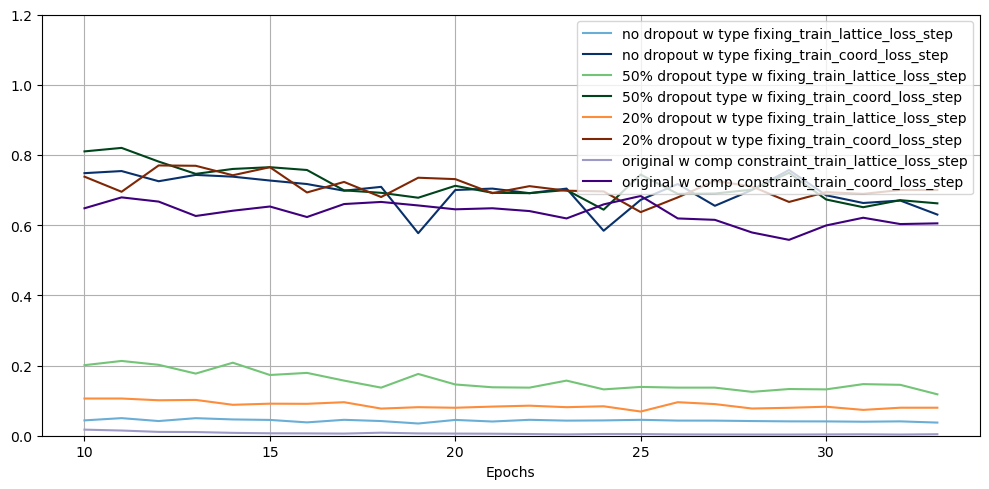

In [9]:
file_paths = {"no dropout w type fixing": "/home/gridsan/tmackey/cdvae/output/no_encode_intensity_concat_comp_concat_neg_mask_type_fixing_24213840_output.txt",
             "50% dropout type w fixing":  "/home/gridsan/tmackey/cdvae/output/drouput_input_layer_v3_24235710_output.txt",
            "20% dropout w type fixing":  "/home/gridsan/tmackey/cdvae/output/dropout_input_layer_20_perov_24254983_output.txt",
             "original w comp constraint": "/home/gridsan/tmackey/cdvae/output/og_CDVAE_dropout_input_layer_24249924_output.txt"}
myepoch_dict =  epoch_dict_getter(file_paths)
mycomponents_to_extract = ['train_lattice_loss_step', 
 'train_coord_loss_step']
neo_plotter(myepoch_dict, mycomponents_to_extract, domain = [10, 34], y_lim = 1.2)

no dropout w type fixing
50% dropout type w fixing
20% dropout w type fixing
original w comp constraint
3000
744
36
3000


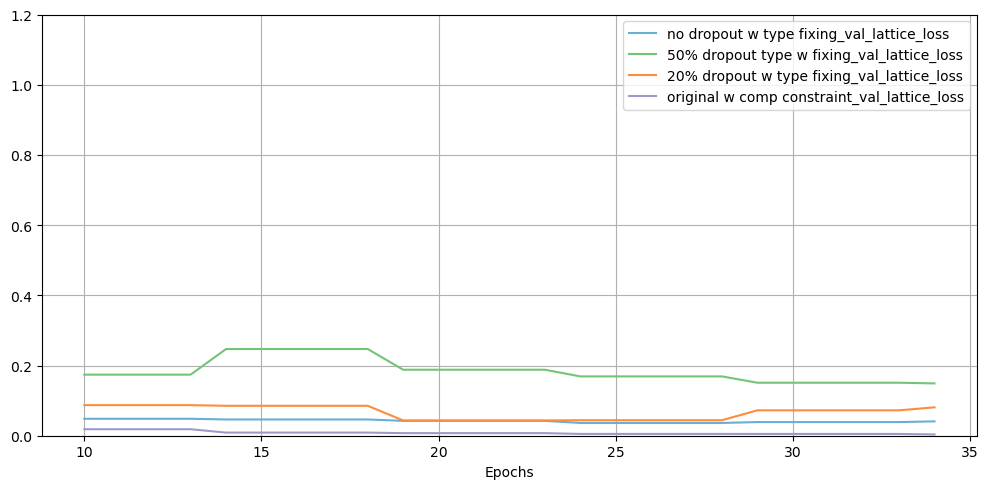

In [11]:
myepoch_dict =  epoch_dict_getter(file_paths)
mycomponents_to_extract = ['val_lattice_loss']
neo_plotter(myepoch_dict, mycomponents_to_extract, domain = [10, 35], y_lim = 1.2)

3000
744
36
3000


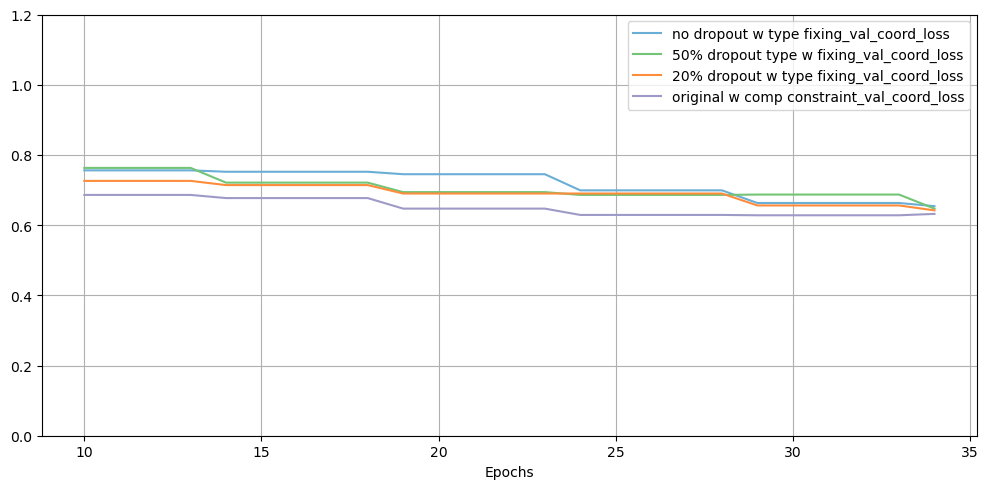

In [12]:
mycomponents_to_extract = ['val_coord_loss']
neo_plotter(myepoch_dict, mycomponents_to_extract, domain = [10, 35], y_lim = 1.2)

no dropout w type fixing
dropout type w fixing
original w comp constraint
3000
744
3000


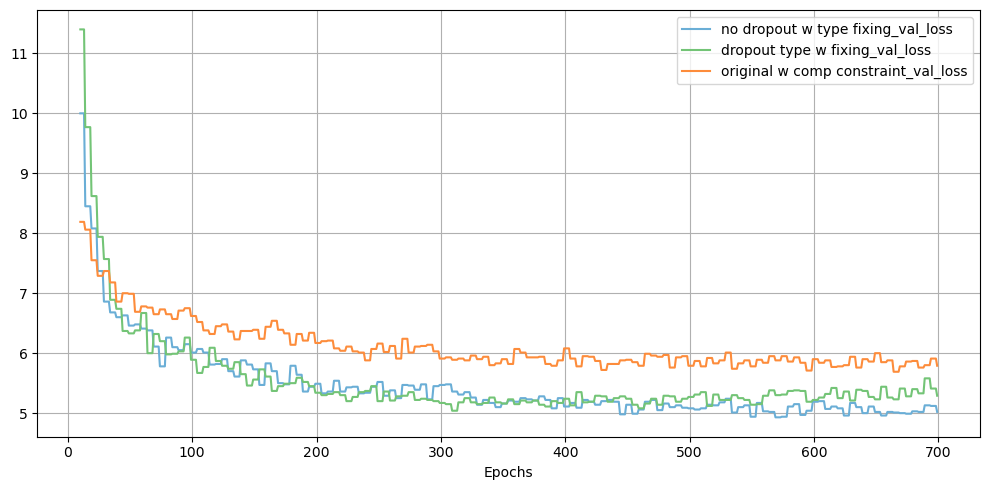

In [14]:
file_paths = {"no dropout w type fixing": "/home/gridsan/tmackey/cdvae/output/no_encode_intensity_concat_comp_concat_neg_mask_type_fixing_24213840_output.txt",
             "dropout type w fixing":  "/home/gridsan/tmackey/cdvae/output/drouput_input_layer_v3_24235710_output.txt",
             "original w comp constraint": "/home/gridsan/tmackey/cdvae/output/og_CDVAE_dropout_input_layer_24249924_output.txt"}
myepoch_dict =  epoch_dict_getter(file_paths)
mycomponents_to_extract = ['val_loss']
neo_plotter(myepoch_dict, mycomponents_to_extract, domain = [10, 700])

no dropout w type fixing
dropout type w fixing
original w comp constraint
3000
744
3000


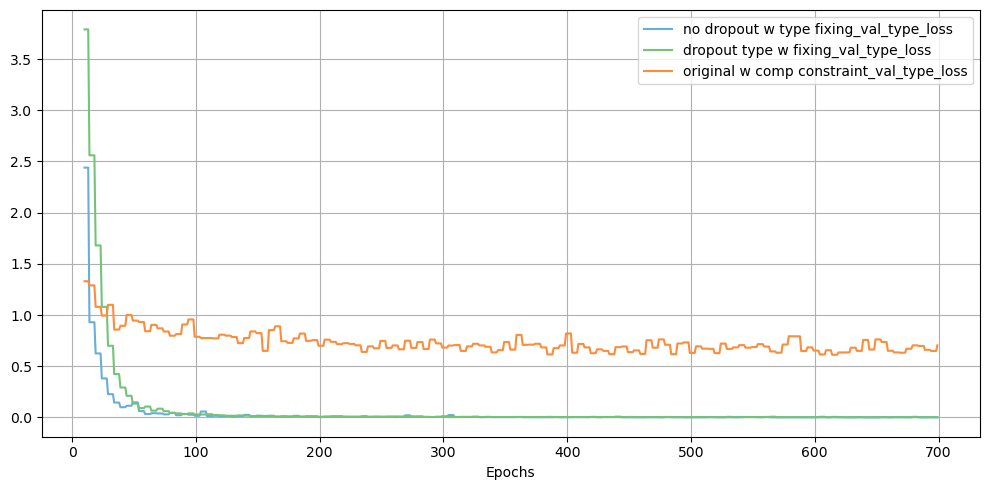

In [16]:
file_paths = {"no dropout w type fixing": "/home/gridsan/tmackey/cdvae/output/no_encode_intensity_concat_comp_concat_neg_mask_type_fixing_24213840_output.txt",
             "dropout type w fixing":  "/home/gridsan/tmackey/cdvae/output/drouput_input_layer_v3_24235710_output.txt",
             "original w comp constraint": "/home/gridsan/tmackey/cdvae/output/og_CDVAE_dropout_input_layer_24249924_output.txt"}
myepoch_dict =  epoch_dict_getter(file_paths)
mycomponents_to_extract = ['val_type_loss']
neo_plotter(myepoch_dict, mycomponents_to_extract, domain = [10, 700])

Looking at the materials project data: 

no dropout w type fixing
dropout type w fixing
original w comp constraint
1000
1000
1000
1000
1000
1000


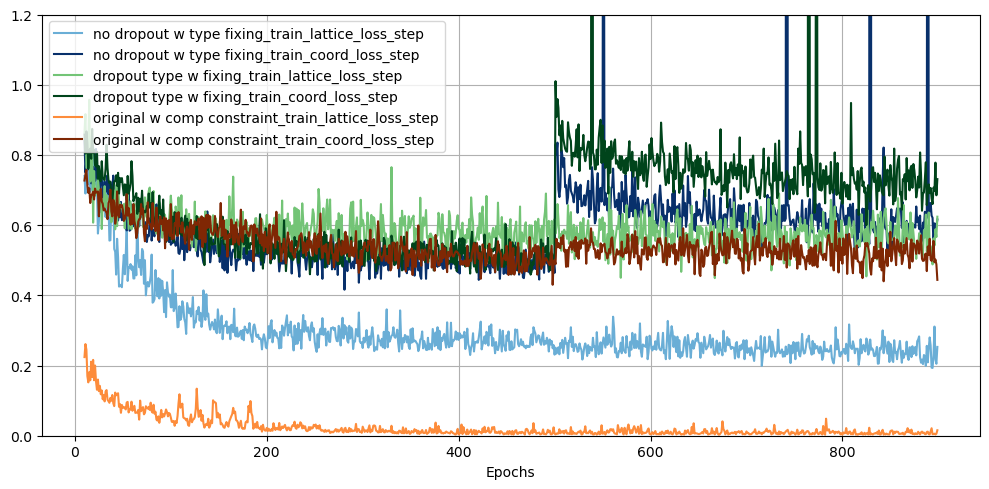

In [10]:
file_paths = {"no dropout w type fixing": "/home/gridsan/tmackey/cdvae/output/no_encode_intensity_concat_comp_concat_neg_mask_type_fixing_mp_20_24213842_output.txt",
             "dropout type w fixing":  "/home/gridsan/tmackey/cdvae/output/dropout_input_layer_v3_mp_20_24235715_output.txt",
             "original w comp constraint": "/home/gridsan/tmackey/cdvae/output/og_CDVAE_neg_mask_mp_20_24141459_output.txt"}
myepoch_dict =  epoch_dict_getter(file_paths)
mycomponents_to_extract = ['train_lattice_loss_step', 
 'train_coord_loss_step']
neo_plotter(myepoch_dict, mycomponents_to_extract, domain = [10, 900], y_lim = 1.2)

no dropout w type fixing
dropout type w fixing
original w comp constraint
1000
1000
1000


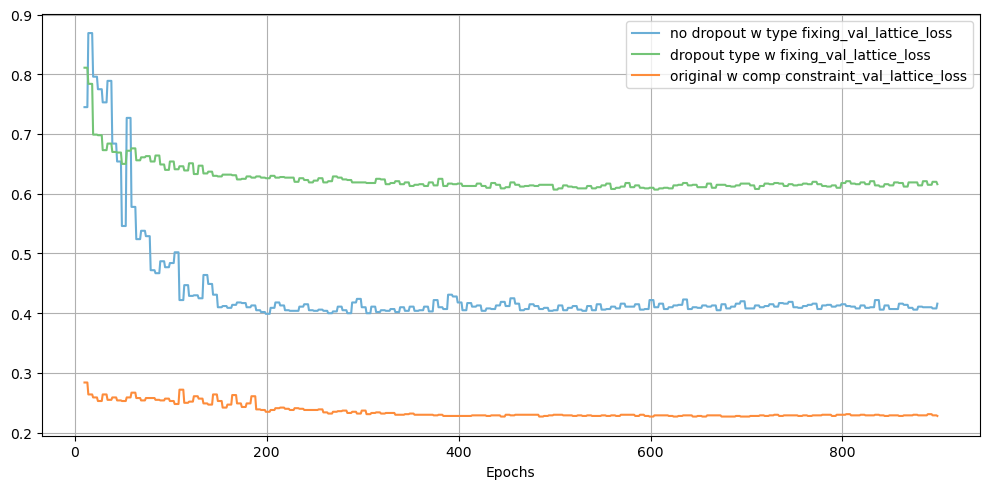

In [20]:
file_paths = {"no dropout w type fixing": "/home/gridsan/tmackey/cdvae/output/no_encode_intensity_concat_comp_concat_neg_mask_type_fixing_mp_20_24213842_output.txt",
             "dropout type w fixing":  "/home/gridsan/tmackey/cdvae/output/dropout_input_layer_v3_mp_20_24235715_output.txt",
             "original w comp constraint": "/home/gridsan/tmackey/cdvae/output/og_CDVAE_neg_mask_mp_20_24141459_output.txt"}
myepoch_dict =  epoch_dict_getter(file_paths)
mycomponents_to_extract = ['val_lattice_loss']
neo_plotter(myepoch_dict, mycomponents_to_extract, domain = [10, 900])

no dropout w type fixing
dropout type w fixing
original w comp constraint
1000
1000
1000


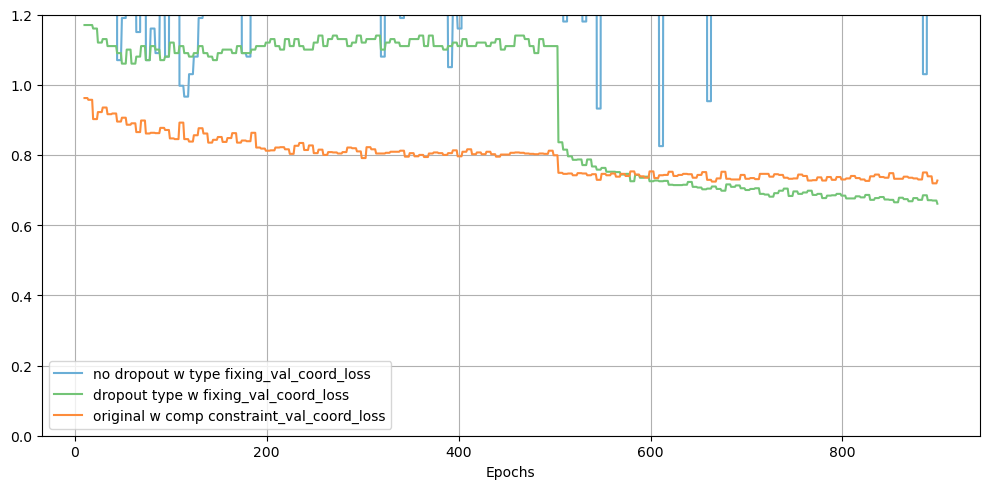

In [14]:
file_paths = {"no dropout w type fixing": "/home/gridsan/tmackey/cdvae/output/no_encode_intensity_concat_comp_concat_neg_mask_type_fixing_mp_20_24213842_output.txt",
             "dropout type w fixing":  "/home/gridsan/tmackey/cdvae/output/dropout_input_layer_v3_mp_20_24235715_output.txt",
             "original w comp constraint": "/home/gridsan/tmackey/cdvae/output/og_CDVAE_neg_mask_mp_20_24141459_output.txt"}
myepoch_dict =  epoch_dict_getter(file_paths)
mycomponents_to_extract = ['val_coord_loss']
neo_plotter(myepoch_dict, mycomponents_to_extract, domain = [10, 900], y_lim = 1.2)

original w comp constraint
3000
3000
3000
3000


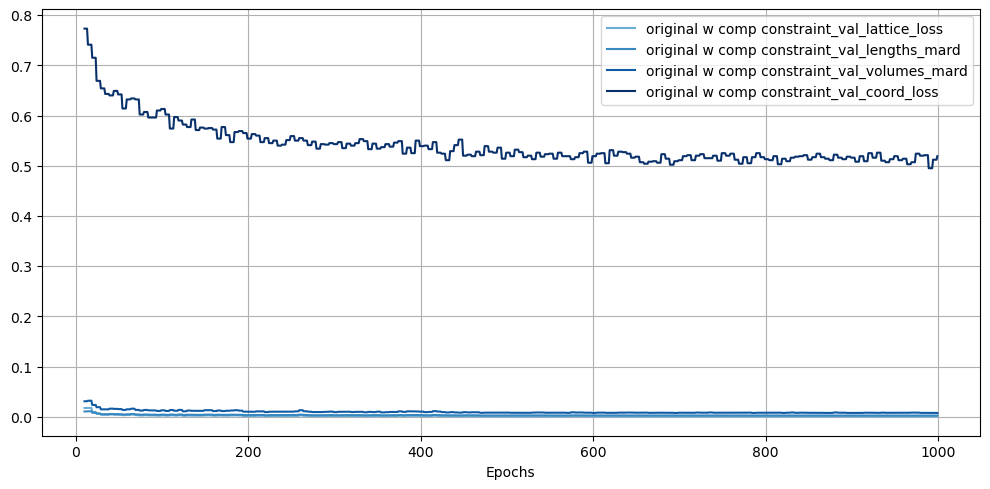

In [17]:
file_paths = {"original w comp constraint": "/home/gridsan/tmackey/cdvae/output/og_CDVAE_no_encode_intensity_concat_comp_concat_neg_mask_1_24114725_output.txt"}
myepoch_dict =  epoch_dict_getter(file_paths)
mycomponents_to_extract = ['val_lattice_loss', 
 'val_lengths_mard', 
 'val_volumes_mard',
 'val_coord_loss']
neo_plotter(myepoch_dict, mycomponents_to_extract)

original w comp constraint
3000
3000
3000


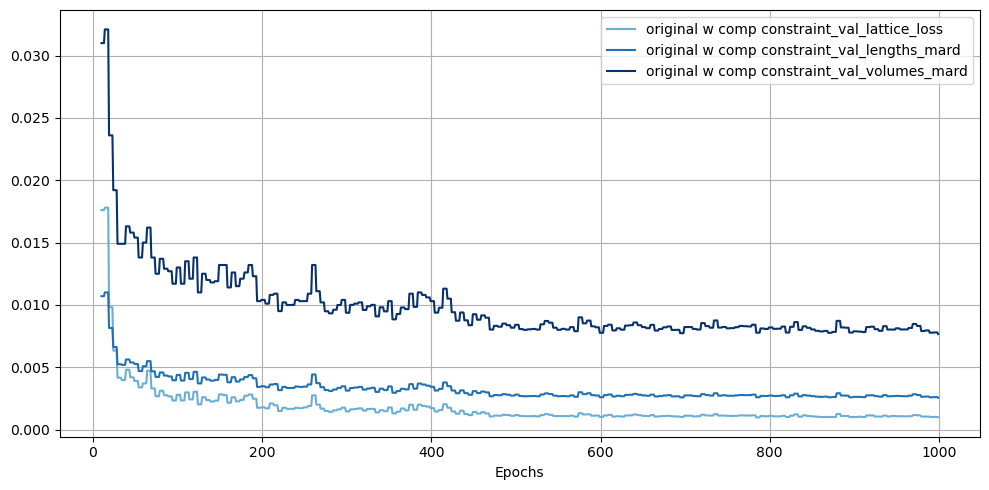

In [18]:
file_paths = {"original w comp constraint": "/home/gridsan/tmackey/cdvae/output/og_CDVAE_no_encode_intensity_concat_comp_concat_neg_mask_1_24114725_output.txt"}
myepoch_dict =  epoch_dict_getter(file_paths)
mycomponents_to_extract = ['val_lattice_loss', 
 'val_lengths_mard', 
 'val_volumes_mard']
neo_plotter(myepoch_dict, mycomponents_to_extract)